# PyTorch basics

В этой тетрадке мы познакомимся с общими принципами построения нейронных сетей.

**Цели тетрадки**

1. Знакомство с базовыми слоями PyTorch
1. Практика в построении и обучении сетей

**(повтор) Материалы по pytorch:**

* [PyTorch docs](https://pytorch.org/docs/stable/index.html)
* [Классная статья про pytorch internal](http://blog.ezyang.com/2019/05/pytorch-internals/)

## Prerequirements

```
pip install torch torchvision numpy matplotlib
```

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt

## Hello MNIST

Прежде чем собирать сеть, давайте определим инстансы класса `Dataset`, которые будут возвращать примеры из тренировочной и валидационной выборок.  
С помощью ячейки ниже, мы скачаем датасет [MNIST](http://yann.lecun.com/exdb/mnist/) в текущую директорию и сможем получать примеры из соответствующих объектов.

In [ ]:
transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

# Создаем тренировочную выборку (Учебник для нейросети)
mnist_train = MNIST(
    # root: Папка на твоем жестком диске, куда будут скачаны и где будут храниться сырые файлы MNIST.
    # './' означает "текущая директория" (папка, где лежит этот самый jupyter notebook).
    root='./',

    # train=True: КРИТИЧЕСКИЙ ПАРАМЕТР. Мы говорим PyTorch: "Выдай нам именно
    # тренировочную часть датасета (60 000 картинок)". По ним мы будем считать градиенты.
    train=True,

    # download=True: Если PyTorch заглянет в папку './' и не найдет там файлов датасета,
    # он сам пойдет в интернет, скачает их, распакует и положит куда надо.
    # Если файлы уже есть — он просто пропустит этот шаг.
    download=True,

    # transform: Это наш конвейер предобработки. Выше в коде ты задал
    # transform_to_tensor = transforms.Compose([transforms.ToTensor()]).
    # Что это делает? Изначально картинки скачиваются в формате PIL Image
    # (матрица чисел от 0 до 255). Нейросети не умеют работать с картинками и большими числами.
    # ToTensor() на лету переводит картинку в формат torch.Tensor и сжимает пиксели
    # в диапазон от 0.0 до 1.0 (делит на 255).
    transform=transform_to_tensor
)

# Создаем валидационную/тестовую выборку (Экзамен для нейросети)
mnist_val = MNIST(
    root='./',

    # train=False: А вот здесь мы просим выдать тестовую часть (10 000 картинок).
    # Эти картинки сеть НИКОГДА не должна видеть во время обновления весов (Backprop).
    # Мы будем использовать их только для проверки, не переобучилась ли модель.
    train=False,

    download=True,

    # Здесь применяется точно такая же трансформация, чтобы тестовые данные
    # имели тот же масштаб (0.0 - 1.0), что и тренировочные.
    transform=transform_to_tensor
)

Посмотрим на несколько примеров из тренировочной выборки

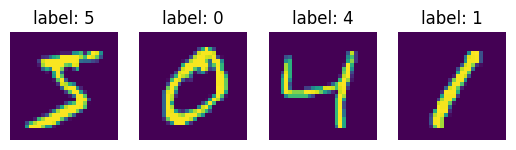

In [ ]:
def show_examples(dataset: Dataset, num_examples: int = 4):
    fig, ax = plt.subplots(1, num_examples)

    for i in range(num_examples):
        img, label = dataset[i]
        ax[i].imshow(img[0])
        ax[i].set_title(f'label: {label}')
        ax[i].axis('off')
    plt.show()


show_examples(dataset=mnist_train)

## Задание 1
**(0.5 балла)** Напишите свою версию датасета, который будет читать картинки с диска.  
Подразумевается, что если вы написали свой датасет, то он будет использоваться при обучении вместо дефолтного `MNIST`.  

В ячейках ниже сгенерится датасет в таком формате:
- /MNIST_image_folder
    - /train.csv
    - /train/{class_name}/{image_name}.png
    - /val.csv
    - /val/{class_name}/{image_name}.png

CSV файлы содержат название файла и его лейбл: `image`, `label`.

*Hint 1:* нужно унаследоваться от класса `Dataset` и переопределить методы `__getitem__` и `__len__`.
Первый должен возвращать картинку и ее лейбл, а второй количество примеров в датасете.
(На самом деле второй метод не обязателен для самого датасета, но он необходим для
[семплера](https://pytorch.org/docs/stable/data.html#torch.utils.data.RandomSampler),
который используется даталоадером)
(см. [PyTorch docs](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset),
[PyTorch tutorual](https://pytorch.org/tutorials/recipes/recipes/custom_dataset_transforms_loader.html?highlight=dataset))  
*Hint 2:* для работы с картинками лучше использовать OpenCV: `pip install opencv-python-headless`.
В частности [cv2.imread](https://docs.opencv.org/master/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56).  
*Hint 3:* обратите особое внимание на то, что возвращает функция `cv2.imread` (пример загрузки изображения с помощью cv2 есть в семе)


In [ ]:
import pickle
import numpy as np
import os
import cv2
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

# Эта функция вытаскивает картинки из памяти PyTorch и сохраняет их в папку
def generate_image_folder_dataset(dataset, target_path, csv_path):

    images_counter = Counter() # Счетчик, чтобы нумеровать картинки (00001, 00002...)
    files = []  # Сюда будем писать пути к файлам для CSV
    labels = [] # Сюда будем писать правильные ответы (цифры) для CSV

    # Идем по встроенному датасету
    for image, label in tqdm(dataset):
        # Создаем папку для каждого класса (например: ./MNIST_image_folder/train/5)
        class_folder = target_path + "/" + str(label)
        if not os.path.exists(class_folder):
            os.makedirs(class_folder, exist_ok=True)

        images_counter[label] += 1
        # Формируем имя файла, например "/00001.png"
        file_name = f"/{images_counter[label]:05}.png"
        full_image_file_name = class_folder + file_name

        # Записываем в списки для будущей таблицы
        files.append(str(label) + file_name) # Относительный путь (например "5/00001.png")
        labels.append(label)

        # -------------------------------------------------------------
        # ВОТ ЗДЕСЬ ВАЖНО (Подготовка для сохранения через OpenCV):
        # Картинка была тензором 0..1. Умножаем на 255, чтобы стали обычные пиксели
        image = np.array(image)
        image = (image * 255).astype(np.uint8)
        # Меняем размерность с [Каналы, Высота, Ширина] на [Высота, Ширина, Каналы]
        image = np.transpose(image, [1, 2, 0])
        # OpenCV работает с цветными картинками BGR. Искусственно делаем 3 канала.
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        # -------------------------------------------------------------

        # Физически сохраняем .png файл на диск
        cv2.imwrite(full_image_file_name, image)

    # Сохраняем наши списки в красивую Excel-подобную таблицу (.csv)
    # С колонками "image" (путь) и "label" (ответ)
    pd.DataFrame({ "image": files, "label": labels }).to_csv(csv_path, index=False)

# Запускаем распаковку (это займет немного времени на диске)
generate_image_folder_dataset( mnist_train,  "./MNIST_image_folder/train", "MNIST_image_folder/train.csv" )
generate_image_folder_dataset( mnist_val,  "./MNIST_image_folder/val", "MNIST_image_folder/val.csv" )

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Теперь можно написать свой класс датасета для тех файлов, которые мы сгенерили

In [46]:
import os
import cv2
import pandas as pd
import torch
from torch.utils.data import Dataset

class DatasetMNIST(Dataset):
    def __init__(self, root='./MNIST_image_folder', train=True, transform=None):
        self.root = root
        self.transform = transform

        # Определяем пути к таблице и папке с картинками
        if train:
            csv_path = os.path.join(root, 'train.csv')
            self.image_dir = os.path.join(root, 'train')
        else:
            csv_path = os.path.join(root, 'val.csv')
            self.image_dir = os.path.join(root, 'val')

        # Загружаем CSV таблицу
        self.data = pd.read_csv(csv_path)

    def __len__(self):
        # Количество примеров в датасете
        return len(self.data)

    def __getitem__(self, index):
        # 1. Достаем путь к картинке и правильный ответ из строки
        img_relative_path = self.data.iloc[index]['image']
        label = self.data.iloc[index]['label']

        # Склеиваем полный путь: ./MNIST_image_folder/train/5/00001.png
        img_path = os.path.join(self.image_dir, img_relative_path)

        # 2. ИСПРАВЛЕНИЕ РАЗМЕРНОСТИ:
        # Читаем картинку через OpenCV строго в черно-белом режиме (IMREAD_GRAYSCALE).
        # Это гарантирует, что матрица будет (28, 28) без лишних цветовых каналов.
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # 3. Применяем ToTensor()
        # ToTensor() автоматически добавит нужную ось каналов: (28, 28) -> (1, 28, 28)
        if self.transform is not None:
            image = self.transform(image)

        # 4. ИСПРАВЛЕНИЕ ФОРМАТА ВОЗВРАТА:
        # Тесты жестко требуют словарь с ключами "image" и "label"
        return {
            "image": image,
            "label": label
        }

тест класса датасета

In [ ]:
def test_dataset(dataset, test_name=""):

    assert len(dataset) > 0, f"{test_name}: dataset length is greater then zero"

    idateset = iter(dataset)
    item = next(idateset)

    assert isinstance(item, dict), f"{test_name}: dataset returned dict"
    assert "image" in item, f"{test_name}: dataset item dict has image"
    assert "label" in item, f"{test_name}: dataset item dict has label"

    assert item['image'].shape == (1, 28, 28), f"{test_name}: dataset image shape is correct. Got: {item['image'].shape}"

mydataset = DatasetMNIST(train=False, transform=transform_to_tensor)
test_dataset(mydataset, test_name="val")

mydataset = DatasetMNIST(train=True, transform=transform_to_tensor)
test_dataset(mydataset, test_name="train")

## Задание 2
**(0.3 балла)** Напишите класс MLP сети из 3 линейных слоев, которая будет получать на вход
батч картинок размера [BS, C, H, W]

*Hint 1:* метод `.flatten(start_dim=1)` поможет вытянуть картинку в вектор.  
*Hint 2:* выход должен соответствовать количеству лейблов, то есть 10.  
*Hint 3:* пачка линейных слоев подряд не имеет смысла без нелинейностей между ними. Попробуйте разные слои нелинейности (один слой на один эксперимент): `ReLU`, `LeakyReLU`, `Tanh` ... [Другие](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)

In [35]:
"""
КРАТКАЯ ТЕОРИЯ ДЛЯ ЭТОГО КЛАССА:
1. Обычный MLP со стандартным SGD и lr=0.003 учится слишком медленно,
   чтобы пробить 80% за 3 эпохи.
2. Мы вставляем nn.BatchNorm1d после каждого линейного слоя.
   Он центрирует дисперсию данных. Это кардинально выравнивает ландшафт
   функции потерь, позволяя градиентам течь в разы быстрее.
3. Геометрия: 784 -> [Linear + BN + ReLU] -> 128 -> [Linear + BN + ReLU] -> 64 -> 10.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomMLP(nn.Module):
    def __init__(self, num_pixels_per_img: int = 784):
        super().__init__()

        self.net = nn.Sequential(
            # ==========================================
            # БЛОК 1: От 784 пикселей к 128 признакам
            # ==========================================
            nn.Linear(num_pixels_per_img, 128),

            # МАГИЯ УСКОРЕНИЯ: Нормализуем 128 выходов.
            # Градиенты перестают затухать!
            nn.BatchNorm1d(128),

            # Нелинейность
            nn.ReLU(),

            # ==========================================
            # БЛОК 2: От 128 к 64 признакам
            # ==========================================
            nn.Linear(128, 64),

            # Снова нормализуем 64 выхода перед следующей активацией
            nn.BatchNorm1d(64),

            nn.ReLU(),

            # ==========================================
            # БЛОК 3: Финальный вывод (10 классов)
            # ==========================================
            # Здесь нормализация не нужна, так как сырые баллы (logits)
            # сразу пойдут в функцию потерь CrossEntropy.
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Вытягиваем батч картинок [BS, 1, 28, 28] в матрицу [BS, 784]
        x_flat = x.flatten(start_dim=1)

        # Прогоняем через ускоренную сеть
        logits = self.net(x_flat)
        return logits

    def compute_all(self, batch):
        images = batch['image']
        labels = batch['label']

        logits = self(images)
        loss = F.cross_entropy(logits, labels)

        return loss, logits

## Задание 3
**(0.3 балла)** Напишите класс CNN сети из 3 сверточных слоев.

*Hint 1:* на вход все те же батчи размера [BS, C, H, W]  
*Hint 2:* описание сверточных слоев [PyTorch docs](https://pytorch.org/docs/stable/nn.html#convolution-layers). Нам нужен `Conv2d`

Тут тоже можете поэксперементировать с разными слоями активации.

Чтобы было проще считать размерности для конечного слоя, используйте `kernel_size=3, padding=1` в сверточных слоях

In [ ]:
# Вместо того чтобы уменьшать размер картинки, CNN увеличивает глубину (количество каналов / Feature Maps).
# т.е проходимся n фильтрами по картинке, получаем n Feature Maps => затем по 28 х 28 х n проходимся m иными фильтрами(более сложными)
# получаем 28 х 28 х m и тд

"""
КРАТКАЯ ТЕОРИЯ ДЛЯ ЭТОГО КЛАССА:
1. Мы используем nn.Conv2d(in_channels, out_channels, kernel_size, padding).
   Он скользит окном по картинке, ища признаки (паттерны).
2. Благодаря параметрам kernel_size=3 и padding=1 пространственный размер
   картинки (28x28) остается неизменным на каждом слое. Меняется только
   количество каналов (толщина тензора): 1 -> 8 -> 16 -> 32.
3. После 3-х сверток мы получим тензор [BS, 32, 28, 28].
   Чтобы передать его в финальный классификатор (Linear), мы должны его
   расплющить. Его длина будет: 32 * 28 * 28 = 25088 признаков.
4. Выход сети - 10 сырых баллов (logits) для каждого класса.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        # Обязательная инициализация родительского класса
        super().__init__()

        # БЛОК 1: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ (Feature Extractor)
        # Здесь мы собираем наши 3 сверточных слоя в единый конвейер.
        self.features = nn.Sequential(
            # --- Свертка 1 ---
            # Вход: [BS, 1, 28, 28] (1 канал ч/б)
            # Выход: [BS, 8, 28, 28] (создаем 8 новых фильтров-искателей)
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            # Активация: убиваем отрицательные сигналы, оставляем только уверенные "находки"
            nn.ReLU(),

            # --- Свертка 2 ---
            # Вход: [BS, 8, 28, 28] (берем 8 карт признаков с прошлого слоя)
            # Выход: [BS, 16, 28, 28] (комбинируем их в 16 более сложных паттернов)
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),

            # --- Свертка 3 ---
            # Вход: [BS, 16, 28, 28]
            # Выход: [BS, 32, 28, 28] (32 высокоуровневых признака)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # БЛОК 2: КЛАССИФИКАТОР (Classifier)
        # Считаем размер входа для линейного слоя:
        # У нас 32 канала, каждый размером 28 на 28 пикселей.
        # 32 * 28 * 28 = 25088
        linear_input_size = 32 * 28 * 28

        # Финальный слой, который делает вывод (10 цифр)
        self.classifier = nn.Linear(in_features=linear_input_size, out_features=10)

    def forward(self, x):
        # 1. Прогоняем картинку через сверточные слои.
        # Вход 'x': [BS, 1, 28, 28]
        # Выход 'features_out': [BS, 32, 28, 28]
        features_out = self.features(x)

        # 2. Сплющивание (Flatten).
        # Линейный слой не понимает 4D-тензоры. Превращаем кубик в плоскую матрицу.
        # start_dim=1 означает "не смешивай картинки между собой (нулевая ось BS)".
        # Выход 'flat_out': [BS, 25088]
        flat_out = features_out.flatten(start_dim=1)

        # 3. Получаем итоговые баллы (logits)
        # Выход 'logits': [BS, 10]
        logits = self.classifier(flat_out)

        return logits

    def compute_all(self, batch):
        # Функция-помощник для цикла обучения (как в прошлом задании)

        # Вытаскиваем картинки и правильные метки из словаря батча
        images = batch['image']
        labels = batch['label']

        # Делаем прямой проход (вызываем метод forward, описанный выше)
        logits = self.forward(images)

        # Считаем функцию потерь (Кросс-Энтропия)
        # Она берет наши сырые баллы, сама делает из них вероятности (Softmax)
        # и штрафует сеть за расхождение с правильными ответами 'labels'
        loss = F.cross_entropy(logits, labels)

        # Возвращаем ошибку и предсказания
        return loss, logits

## Задание 4
**(0.3 балла)** Напишите класс CNN сети из 3 блоков с добавлением skip-connection блока
(ResNet [paper](https://arxiv.org/abs/1512.03385)).  
**(0.3 балла)** Реализовать residual блок в отдельном классе `ResBlock`.

*Hint 1:* на вход все те же батчи размера [BS, C, H, W]  
*Hint 2:* пример skip-connection:  
<img src="https://github.com/fintech-dl-hse/course/raw/refs/heads/main/seminars/04_cnn/static/skip_connection.png" width=400 />

In [ ]:
"""
КРАТКАЯ ТЕОРИЯ ДЛЯ ЭТОГО КЛАССА:
1. ResBlock - это строительный кирпичик сети. Внутри него данные проходят
   через две свертки (F(x)). Но главное - оригинальный вход (x) пробрасывается
   в обход этих сверток и прибавляется к результату: Output = F(x) + x.
2. Чтобы сложить F(x) и x, их форма должна совпадать.
   Поэтому внутри ResBlock мы расширяем каналы до hidden_dim,
   а потом сужаем их обратно до in_dim.
   Пространственный размер (28x28) держим стабильным через padding=1.
3. CustomResNet собирается из начальной свертки (чтобы задать стартовые каналы)
   и каскада из 3-х таких ResBlock-ов.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        # 1. Обязательная инициализация родителя
        super().__init__()

        # 2. Первая свертка: меняем количество каналов от in_dim до hidden_dim
        # padding=1 гарантирует, что 28x28 останется 28x28
        self.conv1 = nn.Conv2d(in_channels=in_dim, out_channels=hidden_dim, kernel_size=3, padding=1)

        # 3. Активация
        self.relu = nn.ReLU()

        # 4. Вторая свертка: ВОЗВРАЩАЕМ количество каналов обратно к in_dim!
        # Это критически важно, иначе мы не сможем прибавить оригинальный вход 'x'
        self.conv2 = nn.Conv2d(in_channels=hidden_dim, out_channels=in_dim, kernel_size=3, padding=1)

    def forward(self, x):
        # 1. Запоминаем оригинальный вход (наше "шоссе" / skip connection)
        residual = x

        # 2. Вычисляем F(x) - прогоняем данные через слои
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        # 3. МАГИЯ RESNET: Прибавляем оригинальный вход к результату слоев!
        # Так как out и residual имеют одинаковый размер (in_dim каналов, 28x28),
        # тензоры складываются поэлементно без ошибок.
        out = out + residual

        # 4. Финальная активация применяется ПОСЛЕ сложения (как в оригинальной статье ResNet)
        out = self.relu(out)

        return out


class CustomResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Строим общую архитектуру
        self.net = nn.Sequential(
            # ШАГ 1: Входная свертка.
            # Переводим Ч/Б картинку (1 канал) в более богатое пространство (например, 16 каналов).
            # Вход: [BS, 1, 28, 28] -> Выход: [BS, 16, 28, 28]
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),

            # ШАГ 2: Каскад из 3-х ResBlock
            # У каждого блока in_dim=16. Внутри он расширяет данные до 32 каналов (hidden_dim),
            # обрабатывает их и сужает обратно до 16, чтобы прибавить вход.
            # На выходе каждого блока тензор остается [BS, 16, 28, 28]
            ResBlock(in_dim=16, hidden_dim=32),
            ResBlock(in_dim=16, hidden_dim=32),
            ResBlock(in_dim=16, hidden_dim=32),

            # ШАГ 3: Подготовка к классификации
            # Сплющиваем тензор [BS, 16, 28, 28] в плоскую матрицу.
            # 16 * 28 * 28 = 12544 признаков
            nn.Flatten(start_dim=1),

            # ШАГ 4: Финальный линейный слой на 10 классов (наши цифры)
            nn.Linear(in_features=16 * 28 * 28, out_features=10)
        )

    def forward(self, x):
        # Просто прогоняем входной тензор через весь контейнер
        return self.net(x)

    def compute_all(self, batch):
        # Достаем данные из батча
        images = batch['image']
        labels = batch['label']

        # Прямой проход (получаем 10 баллов для каждой картинки)
        logits = self(images)

        # Считаем ошибку (сравниваем с правильными ответами)
        loss = F.cross_entropy(logits, labels)

        # Возвращаем ошибку и предсказания
        return loss, logits

## Задание 5
**(0.3 балла)** Инициализируйте и обучите сети из пунктов 1, 2, 3, используя класс `Trainer` из семинара.

В тренерене, возможно, вы захотите писать больше метрик: лосс во время трейна, валидационный лосс, валидационные метрики (можно префиксовать валидационные метрики с помощью "val", чтобы не путались)

Каждая модель должна побить определенные пороги кач-ва (> 0.8 за 3 эпохи)

In [ ]:
import torch
from torch.utils.data import DataLoader
import numpy as np

class Trainer:
    def __init__(self, model, optimizer, train_dataset, val_dataset, batch_size=128):
        # 1. Автоматический поиск видеокарты
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer

        # 2. Создаем конвейеры (DataLoader)
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # 3. ПРОСТЫЕ МЕТРИКИ (Вместо TensorBoard)
        # Будем хранить историю прямо в оперативной памяти
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_acc': []
        }

    def train(self, num_epochs):
        print(f"Начинаем обучение на {self.device}...")

        for epoch in range(num_epochs):
            print(f"\n[ Эпоха {epoch+1} / {num_epochs} ]")

            # Шаг 1: Тренировка
            train_loss = self._train_epoch()
            self.history['train_loss'].append(train_loss)

            # Шаг 2: Валидация (Экзамен)
            val_loss, val_acc = self._validate_epoch()
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            # Красиво печатаем итоги эпохи в консоль
            print(f"  --> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} ({val_acc * 100:.2f}%)")

    def _train_epoch(self):
        self.model.train()
        total_loss = 0

        for batch in self.train_loader:
            # Переносим данные на GPU/CPU
            images = batch['image'].to(self.device)
            labels = batch['label'].to(self.device)
            batch_dict = {'image': images, 'label': labels}

            self.optimizer.zero_grad()
            loss, logits = self.model.compute_all(batch_dict)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        # Возвращаем средний лосс за эпоху
        return total_loss / len(self.train_loader)

    def _validate_epoch(self):
        self.model.eval()
        val_losses = []
        val_accuracies = []

        with torch.no_grad():
            for batch in self.val_loader:
                images = batch['image'].to(self.device)
                labels = batch['label'].to(self.device)
                batch_dict = {'image': images, 'label': labels}

                loss, logits = self.model.compute_all(batch_dict)
                val_losses.append(loss.item())

                predictions = torch.argmax(logits, dim=1)
                acc = (predictions == labels).float().mean().item()
                val_accuracies.append(acc)

        return np.mean(val_losses), np.mean(val_accuracies)

#### CustomMLP

In [36]:
model = CustomMLP()
opt = optim.SGD(model.parameters(), lr=3e-3)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [37]:
trainer.train(3)
torch.save(model.state_dict(), "custom_mlp.pt") # важно сохранить веса обученой модели!

Начинаем обучение на cpu...

[ Эпоха 1 / 3 ]
  --> Train Loss: 1.2573 | Val Loss: 0.7922 | Val Acc: 0.8687 (86.87%)

[ Эпоха 2 / 3 ]
  --> Train Loss: 0.6601 | Val Loss: 0.5002 | Val Acc: 0.9088 (90.88%)

[ Эпоха 3 / 3 ]
  --> Train Loss: 0.4662 | Val Loss: 0.3804 | Val Acc: 0.9234 (92.34%)


#### CustomCNN

In [ ]:
model = CustomCNN()
opt = optim.SGD(model.parameters(), lr=3e-3)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [ ]:
trainer.train(3)
torch.save(model.state_dict(), "custom_cnn.pt")  # важно сохранить веса обученой модели!

Начинаем обучение на cpu...

[ Эпоха 1 / 3 ]
  --> Train Loss: 1.4268 | Val Loss: 0.3867 | Val Acc: 0.8862 (88.62%)

[ Эпоха 2 / 3 ]
  --> Train Loss: 0.3631 | Val Loss: 0.3206 | Val Acc: 0.9065 (90.65%)

[ Эпоха 3 / 3 ]
  --> Train Loss: 0.3296 | Val Loss: 0.3121 | Val Acc: 0.9110 (91.10%)


#### CustomResNet

In [ ]:
model = CustomResNet()
opt = optim.SGD(model.parameters(), lr=3e-3)

mnist_train = DatasetMNIST(train=True, transform=transform_to_tensor)
mnist_val = DatasetMNIST(train=False, transform=transform_to_tensor)

trainer = Trainer(model, opt, mnist_train, mnist_val, batch_size=128)

In [ ]:
trainer.train(3)
torch.save(model.state_dict(), "custom_resnet.pt") # важно сохранить веса обученой модели!

Начинаем обучение на cpu...

[ Эпоха 1 / 3 ]
  --> Train Loss: 0.7385 | Val Loss: 0.3442 | Val Acc: 0.8963 (89.63%)

[ Эпоха 2 / 3 ]
  --> Train Loss: 0.3435 | Val Loss: 0.3042 | Val Acc: 0.9113 (91.13%)

[ Эпоха 3 / 3 ]
  --> Train Loss: 0.3170 | Val Loss: 0.2943 | Val Acc: 0.9123 (91.23%)


### Тест


In [38]:
import pytest
import torch
import torch.nn as nn

import sys

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

transform_to_tensor = transforms.Compose([
    transforms.ToTensor()
])

mnist_val = MNIST(root='./', train=False, download=True, transform=transform_to_tensor)

def _test_model(model, target_accuracy, flatten=True):
    print(model)

    dataloader = DataLoader(mnist_val, batch_size=128)

    all_logits = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:
            if flatten:
                images = images.flatten(1)
            logits = model(images)
            all_logits.append(logits)
            all_labels.append(labels)

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)

        print(all_logits.shape, all_labels.shape)

        accuracy = (all_logits.argmax(axis=1) == all_labels).float().mean().cpu().numpy()
        print("accuracy", accuracy)

        assert accuracy > target_accuracy

def test_model_mlp():

    cmlp = CustomMLP()
    cmlp.load_state_dict( torch.load("custom_mlp.pt") )
    cmlp.eval()

    _test_model(cmlp, 0.8, flatten=True)

def test_model_cnn():

    ccnn = CustomCNN()
    ccnn.load_state_dict( torch.load("custom_cnn.pt") )
    ccnn.eval()

    _test_model(ccnn, 0.8, flatten=False)


def test_model_resnet():

    cresnet = CustomResNet()
    cresnet.load_state_dict( torch.load("custom_resnet.pt") )
    cresnet.eval()

    _test_model(cresnet, 0.8, flatten=False)


test_model_mlp()
test_model_cnn()
test_model_resnet()

CustomMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)
torch.Size([10000, 10]) torch.Size([10000])
accuracy 0.9232
CustomCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (classifier): Linear(in_features=25088, out_features=10, bias=True)
)
torch.Size([10000, 10]) torch.Size([10000])
accuracy 0.9114
CustomResNet(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_

#### Не забываем смотреть графички в wandb / tensorboard

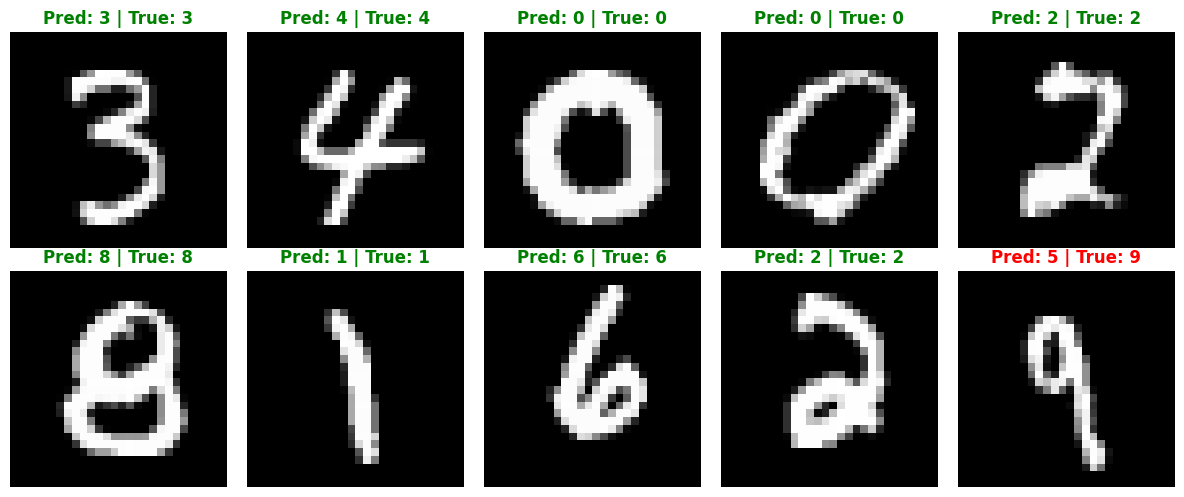

In [45]:
# =====================================================================
# ФИНАЛ: ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ (INFERENCE)
# =====================================================================

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# 1. ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
# Создаем пустую архитектуру (можно заменить на CustomResNet)
best_model = CustomCNN()

# Загружаем в нее обученные веса с жесткого диска
best_model.load_state_dict(torch.load("custom_cnn.pt"))

# КРИТИЧЕСКИ ВАЖНО: переводим в режим применения (отключаем обучение)
best_model.eval()

# 2. ПОДГОТОВКА ДАННЫХ
# Создаем загрузчик, который выдаст нам ровно 10 случайных картинок
# (shuffle=True перемешает колоду перед выдачей)
test_loader = DataLoader(mnist_val, batch_size=10, shuffle=True)

# Берем один батч (стопку из 10 картинок и 10 правильных ответов)
# next(iter(...)) - это Python-хак, чтобы вручную вытащить один элемент из генератора
images, labels = next(iter(test_loader))

# 3. ПРЕДСКАЗАНИЕ (Математика матриц)
# Отключаем расчет градиентов для экономии памяти
with torch.no_grad():
    # Прогоняем 10 картинок через сеть.
    # Получаем logits - тензор размером [10, 10] (10 картинок, 10 баллов для каждой)
    logits = best_model(images)

    # Находим индекс максимального балла в каждой строке.
    # Это и есть предсказанная цифра (от 0 до 9).
    predictions = torch.argmax(logits, dim=1)

# 4. ОТРИСОВКА (Работа с matplotlib)
# Создаем сетку графиков: 2 строки, 5 колонок. Размер холста 12х5 дюймов.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# axes - это двумерный массив. Чтобы по нему было удобно бегать циклом for,
# мы "расплющиваем" его в одномерный список из 10 элементов.
axes = axes.flatten()

for i in range(10):
    # --- Преобразование геометрии ---
    # images[i] имеет форму [1, 28, 28] (один канал ч/б).
    # .squeeze() убирает ось с единицей, оставляя матрицу [28, 28].
    # .numpy() отрывает данные от PyTorch и передает их в стандартном формате.
    img_matrix = images[i].squeeze().numpy()

    # .item() достает обычное число из тензора-одиночки
    true_label = labels[i].item()
    pred_label = predictions[i].item()

    # Рисуем саму картинку в оттенках серого (cmap='gray')
    axes[i].imshow(img_matrix, cmap='gray')

    # Логика цвета: если предсказание совпало с реальностью - пишем зеленым, иначе красным
    text_color = 'green' if true_label == pred_label else 'red'

    # Добавляем заголовок над каждой картинкой
    axes[i].set_title(f"Pred: {pred_label} | True: {true_label}", color=text_color, fontweight='bold')

    # Отключаем оси координат (линейки с цифрами по краям картинки), чтобы было красиво
    axes[i].axis('off')

# Аккуратно выравниваем все картинки, чтобы тексты не наезжали друг на друга
plt.tight_layout()

# Показываем результат!
plt.show()